# Prosjektoppgave

#### Karina Skjelvik (karinaskjelvik@gmail.com)

### Del a)

In [8]:
import pandas as pd
import numpy as np

## Lese inn excel filen "support_uke_24.xlsx"
data = pd.read_excel("support_uke_24.xlsx")

## Lag en array for hver av kolonnene i excel filen med variabelnavn hhv. u_dag, kl_slett, varighet, score
array = data.to_numpy()

u_dag = array[:, 0]
kl_slett = array[:, 1]
varighet = array[:, 2]
score = array[:, 3]

## Skriv ut arrayene
print("u_dag:", u_dag)
print("kl_slett:", kl_slett)
print("varighet:", varighet)
print("score:", score)


u_dag: ['Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag'
 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag'
 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag'
 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag'
 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag'
 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag'
 'Mandag' 'Mandag' 'Mandag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag'
 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag'
 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag'
 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag'
 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag'
 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag'
 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Onsdag' 'Onsdag'
 'Onsdag' 'Onsdag' 'Onsdag' 'Onsdag' 'Onsdag' 'Onsdag' 'Onsdag'

### Del b)

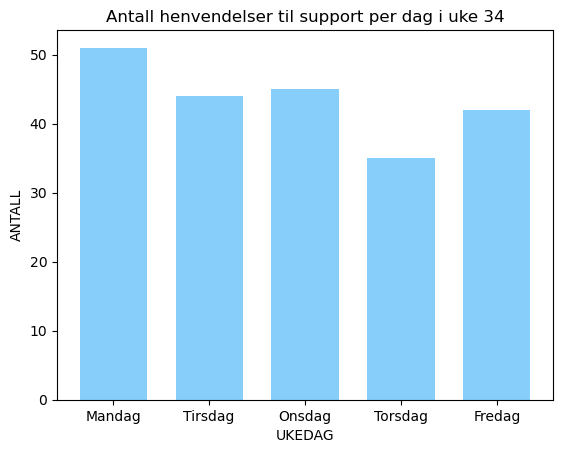

In [9]:
import matplotlib.pyplot as plt

# Definerer rekkefølgen på ukedagene for å få ukedagene i ønsket rekkefølge i søylediagrammet
ukedager = ["Mandag", "Tirsdag", "Onsdag", "Torsdag", "Fredag"]

# Finn antall hendvendelser per ukedag. Lager først en tom liste som fylles med antall hendvendelser per ukedag
antall_per_dag = []
for dag in ukedager:
    antall = np.sum(u_dag == dag)
    antall_per_dag.append(antall)

## Lag Søylediagram 
plt.figure()
plt.bar(ukedager,antall_per_dag, color = ['lightskyblue'], width=0.7) 
plt.xlabel("UKEDAG")
plt.ylabel("ANTALL")
plt.title("Antall henvendelser til support per dag i uke 34")
plt.show()


### Del C)

In [10]:
minste = np.min(varighet)   #Finner minste samtaletid
lengste = np.max(varighet)  #Finner lengste samtaletid

print("Minste samtaletid som er loggført i uke 24 er:", minste)
print("Lengste samtaletid som er loggført i uke 24 er:", lengste)

Minste samtaletid som er loggført i uke 24 er: 00:00:59
Lengste samtaletid som er loggført i uke 24 er: 00:11:28


### Del D)

In [11]:
## For å regne gjennomsnittelig samtaletid må tidene regnes om til sekunder

sekunder = []       #Lager en tom liste

for tid in varighet:
    t, m, s = tid.split(":")        #For-løkken deler opp tidene ved ":" og lager tre variabler for time, minutt, sekund (t, m, s) 
    sekund = int(t)*3600 + int(m)*60 + int(s)     #Varigheten gjøres om til antall sekunder
    sekunder.append(sekund)         #Resultatet (antall sekunder) legges inn i den tomme listen, "sekunder", som vi laget

sekunder = np.array(sekunder)    #Gjør om listen til en NumPy array

## Gjennomsnittnlig sekunder per samtaletid
gjennomsnitt_sekunder = np.average(sekunder)    



# For å vise gjennomsnittlig samtaletid i minutter, regne vi om sekunder til minutter
#Bruker divmod for å dele total_sekunder på 60, gir heltallsresultatet av delingen (antall minutt) og resten etter deling (antall sekunder)
minutter, resterende_sekunder =divmod(gjennomsnitt_sekunder, 60) 
print(f"Gjennomsnittelig samtaletid er: {gjennomsnitt_sekunder:.0f} sekunder, eller, {minutter:.0f} min og {resterende_sekunder:.0f} sek")


Gjennomsnittelig samtaletid er: 400 sekunder, eller, 6 min og 40 sek


### Del E)

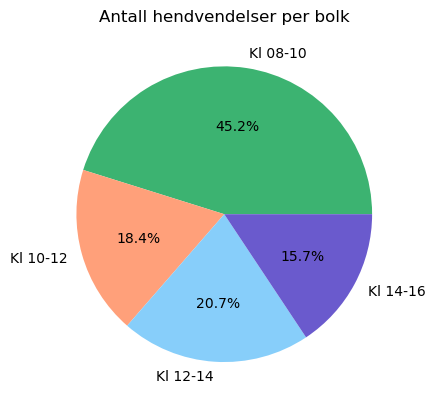

In [12]:
#Lager en teller-variabel for hver av bolkene 
bolk_08_til_10 = 0
bolk_10_til_12 = 0
bolk_12_til_14 = 0
bolk_14_til_16 = 0
stengt = 0

# Finne timen fra hvert klokkeslett
for tid in kl_slett:
    time = int(tid.split(":")[0])

# Bruker sommenlikningsoperatorer og logisk kombinasjon "and" for å sjekke om timen er innenfor en gitt bolk. Dersom "true" økes teller-variabel med 1
    if ((time >= 8 ) and (time < 10)):
        bolk_08_til_10 += 1
    elif ((time >= 10) and (time < 12)):
        bolk_10_til_12 += 1
    elif ((time >= 12) and (time < 14)):
        bolk_12_til_14 += 1
    elif ((time >= 14) and (time < 16)):
        bolk_14_til_16 += 1
    else:
        stengt += 1

# Visualiser resultatene i et sektordiagram
bolker = [bolk_08_til_10, bolk_10_til_12, bolk_12_til_14, bolk_14_til_16]
tekst = ["Kl 08-10", "Kl 10-12", "Kl 12-14", "Kl 14-16"]
farger = ["mediumseagreen", "lightsalmon", "LightSkyBlue", "slateblue"]

plt.figure()
plt.pie(bolker, labels=tekst, autopct="%1.1f%%", colors=farger)
plt.title("Antall hendvendelser per bolk")
plt.show()


### Del F)

In [14]:
#Lager en teller-dictionary som holder alle NPS-scorene

teller = {"negativ": 0, "noytral": 0, "positiv": 0, "ingen_tilbakemelding": 0}

# Sjekker først om resulatet er NaN (ingen verdi). Dersom "true" økes teller-variabel "ingen_tilbakemelding" med 1. 
# Deretter sjekkes det om score er mellom 1-6, 7-8 eller 9-10. Dersom "true" økes teller-variabel med 1.

for resultat in score:

    if np.isnan(resultat):
        teller["ingen_tilbakemelding"] += 1

    else:
        res = int(resultat)
        
        if ((res >= 1 ) and (res <= 6)):
            teller["negativ"] += 1
        elif ((res >= 7) and (res <= 8)):
            teller["noytral"] += 1
        elif ((res >= 9) and (res <= 10)):
            teller["positiv"] += 1

# Finne antall som gav tilbakemelding
antall_svar = teller["negativ"] + teller["noytral"] + teller["positiv"]

# Finne prosent postive og prosent negative kunder
prosent_positiv = teller["positiv"] / antall_svar
prosent_negativ = teller["negativ"] / antall_svar

NPS = (prosent_positiv - prosent_negativ) * 100

#Skriv ut svaret til skjerm

print(f'Supporteravdelingens NPS er: {NPS:.0f}')



Supporteravdelingens NPS er: 42
